In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.drop_duplicates()
df.shape

(299, 9)

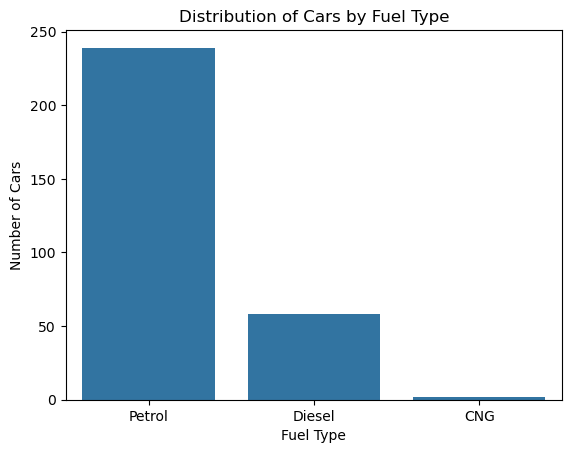

In [33]:
sns.countplot(x="Fuel_Type", data=df)

plt.title("Distribution of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.savefig("../images/fuel_type_distribution.png", bbox_inches="tight")
plt.show()

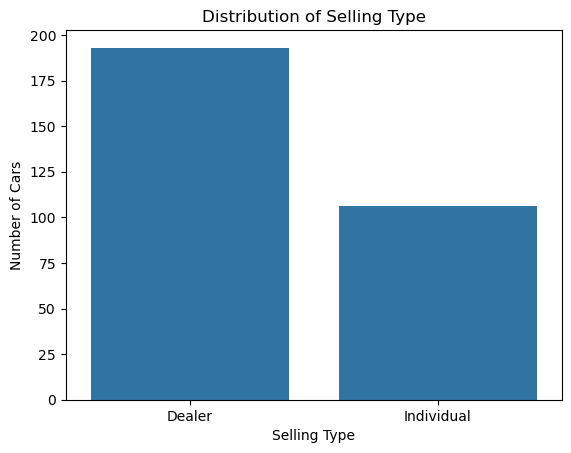

In [34]:
sns.countplot(x="Selling_type", data=df)

plt.title("Distribution of Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Number of Cars")
plt.savefig("../images/selling_type_distribution.png", bbox_inches="tight")
plt.show()

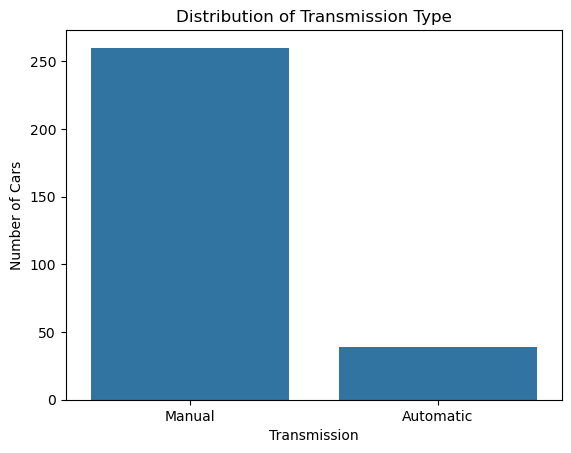

In [35]:
sns.countplot(x="Transmission", data=df)

plt.title("Distribution of Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")
plt.savefig("../images/transmission_distribution.png", bbox_inches="tight")
plt.show()

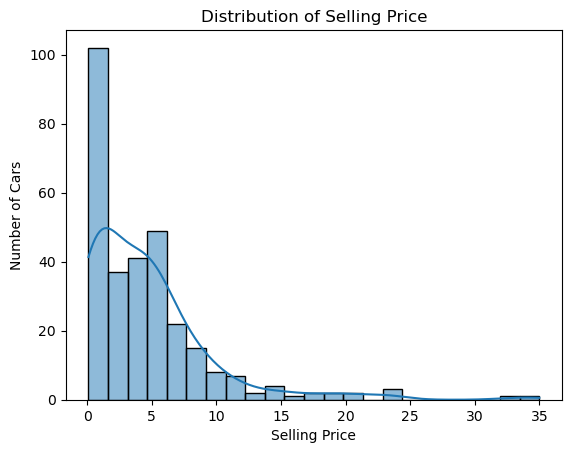

In [36]:
sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.savefig("../images/selling_price_distribution.png", bbox_inches="tight")
plt.show()

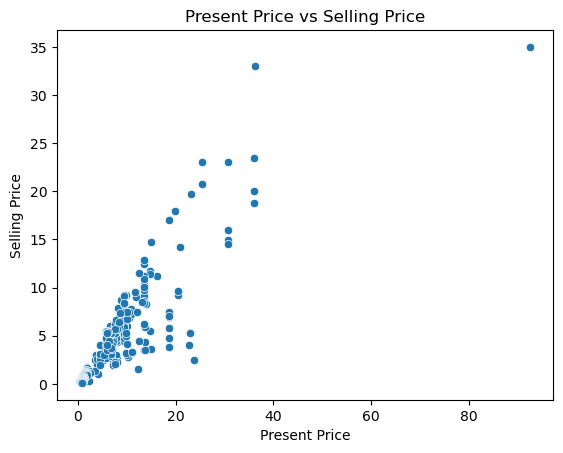

In [38]:
sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.savefig("../images/present_price_vs_selling_price.png", bbox_inches="tight")
plt.show()

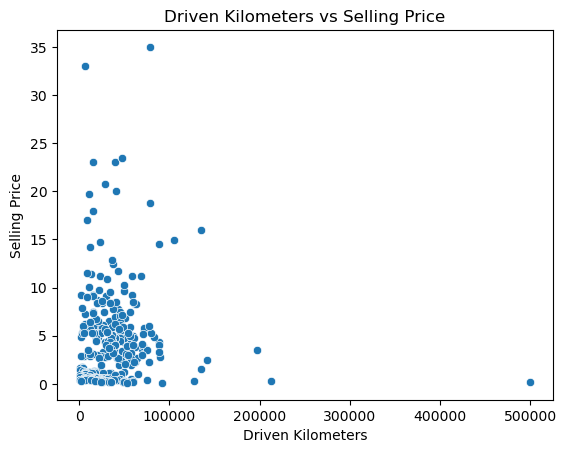

In [39]:
sns.scatterplot(x="Driven_kms", y="Selling_Price", data=df)

plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")

plt.show()

In [40]:
corr = df[[
    "Year",
    "Selling_Price",
    "Present_Price",
    "Driven_kms",
    "Owner"
]].corr()

corr

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000


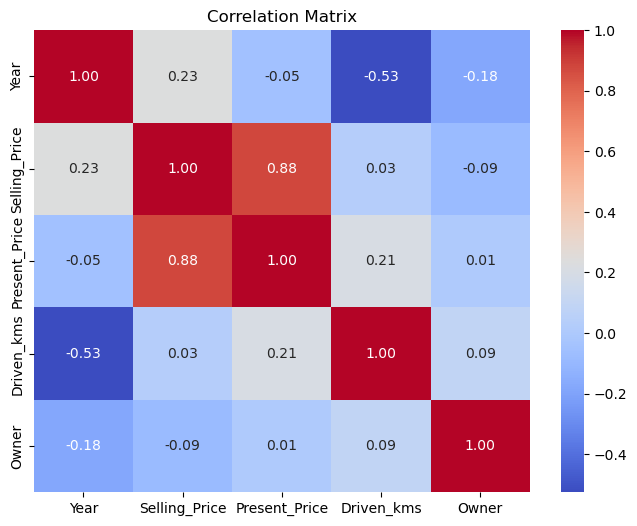

In [41]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

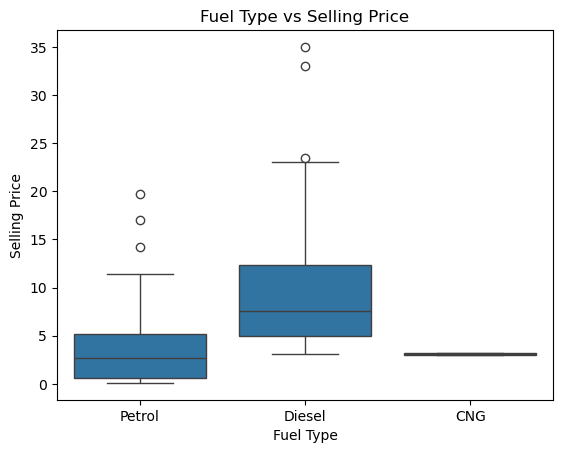

In [42]:
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

plt.title("Fuel Type vs Selling Price")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

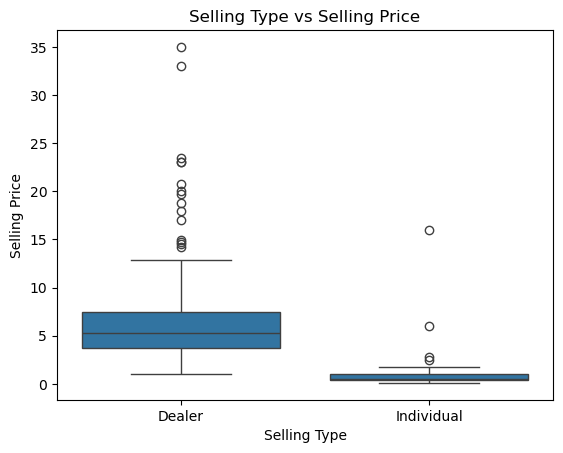

In [43]:
sns.boxplot(x="Selling_type", y="Selling_Price", data=df)

plt.title("Selling Type vs Selling Price")
plt.xlabel("Selling Type")
plt.ylabel("Selling Price")

plt.show()

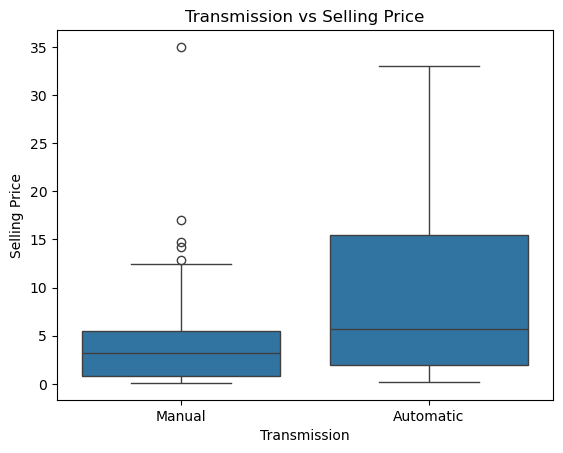

In [44]:
sns.boxplot(x="Transmission", y="Selling_Price", data=df)

plt.title("Transmission vs Selling Price")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

In [22]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]

In [23]:
X.head()

,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,5.59,27000,Petrol,Dealer,Manual,0
1,2013,9.54,43000,Diesel,Dealer,Manual,0
2,2017,9.85,6900,Petrol,Dealer,Manual,0
3,2011,4.15,5200,Petrol,Dealer,Manual,0
4,2014,6.87,42450,Diesel,Dealer,Manual,0


In [24]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [25]:
X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True,
    dtype=int
)

X.head()

,Year,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,5.59,27000,0,0,1,0,1
1,2013,9.54,43000,0,1,0,0,1
2,2017,9.85,6900,0,0,1,0,1
3,2011,4.15,5200,0,0,1,0,1
4,2014,6.87,42450,0,1,0,0,1


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     299 non-null    int64  
 1   Present_Price            299 non-null    float64
 2   Driven_kms               299 non-null    int64  
 3   Owner                    299 non-null    int64  
 4   Fuel_Type_Diesel         299 non-null    int64  
 5   Fuel_Type_Petrol         299 non-null    int64  
 6   Selling_type_Individual  299 non-null    int64  
 7   Transmission_Manual      299 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 21.0 KB


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [29]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,7.500495
1,8.35,7.791134
2,0.45,1.365253
3,7.45,7.008954
4,5.25,11.165011
5,5.25,4.533817
6,5.85,8.491541
7,1.15,1.699151
8,9.25,8.822632
9,0.38,-0.963260


In [31]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.472545750817953
Mean Squared Error: 6.373125106262411
Root Mean Squared Error: 2.524504923002213
R² Score: 0.7527233824219824


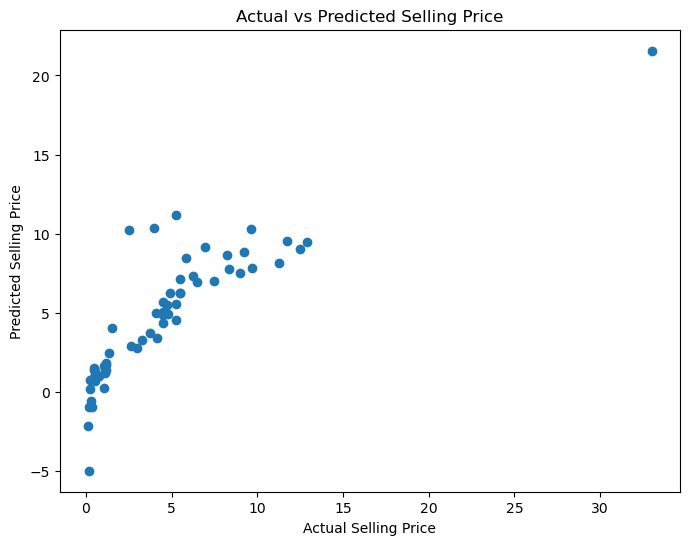

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.savefig("../images/actual_vs_predicted.png", bbox_inches="tight")
plt.show()